# **Nonlinear Models vs. Sochi Weather**
## **Bicycle Demand Forecasting — BikeSochi**

The company **BikeSochi**, an operator of city bike rentals in Sochi, sought help in improving the hourly bike demand forecasting system.

Previously, the company's analysts used simple linear regression — one of the most basic machine learning models.

However, its forecasts were often inaccurate:

> "The model saw that the temperature had risen — and immediately predicted high demand.
But it did not understand that +28 °C under the blazing sun and +28 °C after rain are two completely different situations."

Weather in Sochi changes quickly, and the influence of factors is nonlinear: temperature, humidity, solar radiation, and precipitation affect people's behavior not through simple direct dependencies.



---



## 1. Baseline model

The company provided a ready-trained pipeline with linear regression.
Let's evaluate its quality on the training and test datasets.

In [1]:
!pip install -q optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
import pandas as pd
import numpy as np
import joblib
import requests

from io import BytesIO

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

In [3]:
# Load test data
url_test = 'https://drive.google.com/uc?id=18ai4Uy7lb7Kj1tK2KnqHJlgFwzr3EafR'
test_data = pd.read_csv(url_test)

# Rename columns to pipeline format
rename_map = {
    'Temperature': 'temperature',
    'Humidity(%)': 'humidity',
    'Wind speed (m/s)': 'wind_speed_ms',
    'Visibility (10m)': 'visibility_10m',
    'Dew point temperature': 'dew_point_temperature',
    'Solar Radiation (MJ/m2)': 'solar_radiation_mjm2',
    'Rainfall(mm)': 'rainfallmm',
    'Snowfall (cm)': 'snowfall_cm',
    'Seasons': 'seasons',
    'Holiday': 'holiday',
    'Functioning Day': 'functioning_day',
    'Time_Period_Evening': 'time_period_evening',
    'Time_Period_Late Evening': 'time_period_late_evening',
    'Time_Period_Morning': 'time_period_morning',
    'Time_Period_Night': 'time_period_night',
    'Rented Bike Count': 'rented_bike_count'
}
test_data = test_data.rename(columns=rename_map)

# Split into features and target variable
X_test = test_data.drop('rented_bike_count', axis=1)
y_test = test_data['rented_bike_count']

# Load baseline pipeline
url_pipeline = 'https://drive.google.com/uc?id=1Bbvy9A53k2hnDZ46v1SFM4cZsA26g74F'
response = requests.get(url_pipeline)
pipeline = joblib.load(BytesIO(response.content))

# Make predictions
y_pred = pipeline.predict(X_test)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RMSE_test: {rmse:.4f}')
print(f'MAE_test:  {mae:.4f}')
print(f'R2_test:   {r2:.4f}')

In [4]:
# Load train data
url_train = 'https://drive.google.com/uc?id=1tPlXTFn41A79ATfMxUIJDNL6JbuvrlVM'
train_data = pd.read_csv(url_train)
train_data = train_data.rename(columns=rename_map)

X_train = train_data.drop('rented_bike_count', axis=1)
y_train = train_data['rented_bike_count']

y_pred_train = pipeline.predict(X_train)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train  = mean_absolute_error(y_train, y_pred_train)
r2_train   = r2_score(y_train, y_pred_train)

print(f'RMSE_train: {rmse_train:.4f}')
print(f'MAE_train:  {mae_train:.4f}')
print(f'R2_train:   {r2_train:.4f}')

Metrics on the training and test sets are very close. This indicates that the model has practically not overfitted and has similar quality on the data used for training and on new data. However, the absolute quality of the model remains moderate (for example, r2 is only 0.59, RMSE of 412 bicycles indicates a fairly high average prediction error). It is likely that the linear model is not able to fully describe the complex nonlinear relationships between demand, weather conditions, time of day, and other factors. Therefore, an improvement in forecasting quality can be expected when using more flexible nonlinear models.

## 2. Data Exploration (EDA)

Let's load the training dataset and conduct an initial analysis:
we will look at data types, missing values, and basic statistics.

In [5]:
print('Sample size:', train_data.shape)
print()
print('Data types and missing values:')
print(train_data.info())
print()
print('Basic statistics:')
train_data.describe()

In [6]:
# Count missing values
missing = train_data.isnull().sum()
missing_pct = (missing / len(train_data) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
})

print(missing_df[missing_df['Missing'] > 0])

6 numerical features contain missing values — from 3% to 3.75%.  
This is a small amount, especially considering that this is weather statistics for a single city, so we will fill them with median values  
at the data preparation stage.

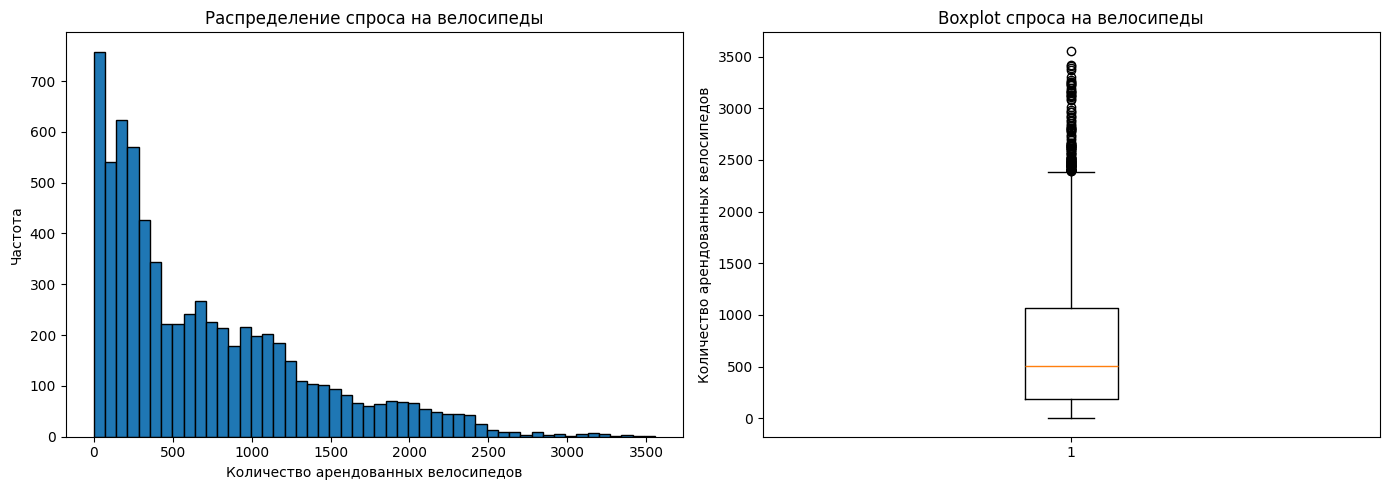

In [7]:
# Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_data['rented_bike_count'], bins=50, edgecolor='black')
axes[0].set_title('Bike Demand Distribution')
axes[0].set_xlabel('Number of Rented Bikes')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(train_data['rented_bike_count'], vert=True)
axes[1].set_title('Bike Demand Boxplot')
axes[1].set_ylabel('Number of Rented Bikes')

plt.tight_layout()
plt.show()

print(f"Mean:  {train_data['rented_bike_count'].mean():.0f}")
print(f"Median:  {train_data['rented_bike_count'].median():.0f}")
print(f"Max:     {train_data['rented_bike_count'].max():.0f}")
print(f"Min:      {train_data['rented_bike_count'].min():.0f}")

From the graphs, it can be seen that:
- The distribution is **right-skewed** — there are peaks up to 3556 bicycles (this is also confirmed by the fact that the mean (706) is noticeably higher than the median (504)).
- The boxplot shows many outliers at the top — there are hours with very high demand.
- Minimum = 0 — these are maintenance hours (Functioning Day = No).

This distribution explains why linear regression performs poorly:
it does not handle skewed distributions and outliers well.

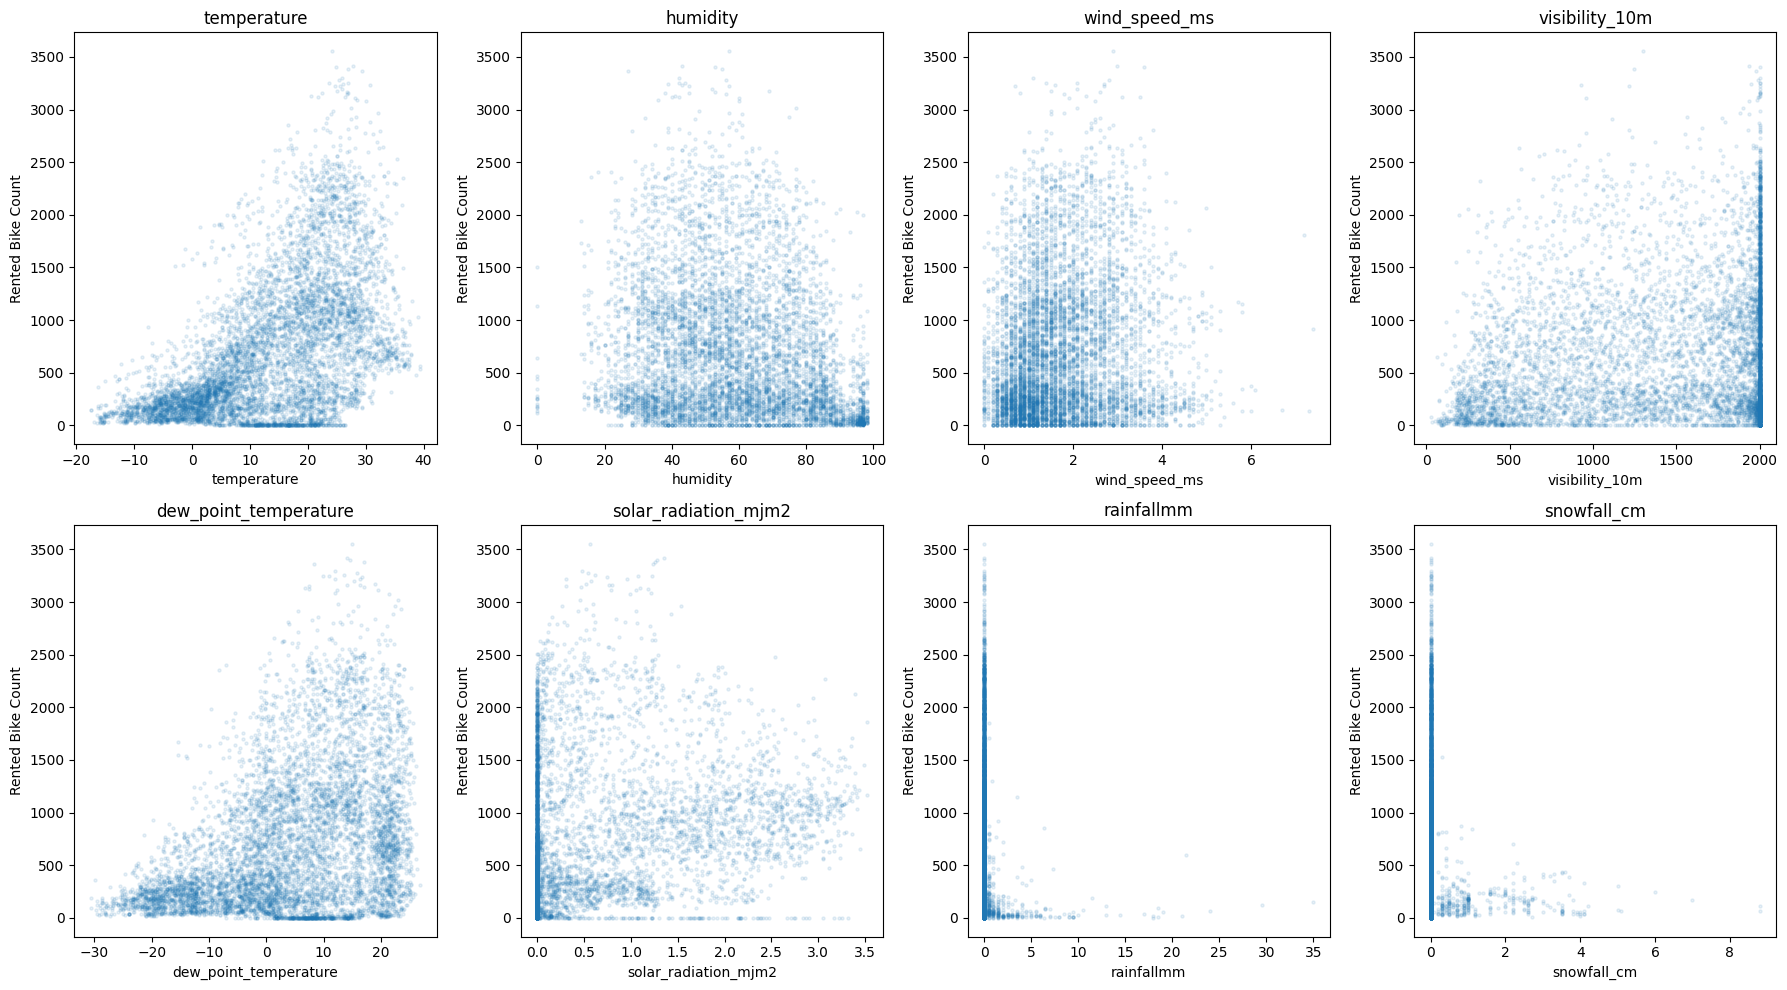

In [8]:
# Relationship of features with the target variable
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# Numerical features
num_features = ['temperature', 'humidity', 'wind_speed_ms',
                'visibility_10m', 'dew_point_temperature',
                'solar_radiation_mjm2', 'rainfallmm', 'snowfall_cm']

for i, feature in enumerate(num_features):
    row, col = i // 4, i % 4
    axes[row, col].scatter(train_data[feature],
                           train_data['rented_bike_count'],
                           alpha=0.1, s=5)
    axes[row, col].set_title(feature)
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Rented Bike Count')

plt.tight_layout()
plt.show()

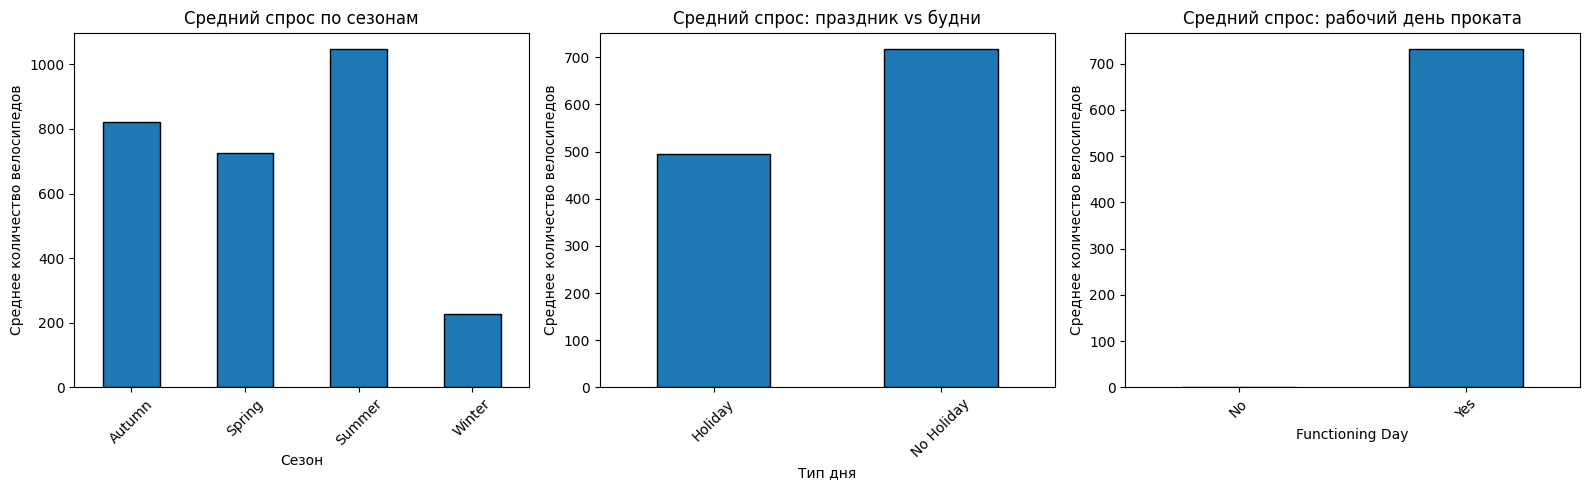

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Seasons
train_data.groupby('seasons')['rented_bike_count'].mean().plot(
    kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Average demand by seasons')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Average number of bikes')
axes[0].tick_params(axis='x', rotation=45)

# Holiday
train_data.groupby('holiday')['rented_bike_count'].mean().plot(
    kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Average demand: holiday vs weekdays')
axes[1].set_xlabel('Day type')
axes[1].set_ylabel('Average number of bikes')
axes[1].tick_params(axis='x', rotation=45)

# Functioning Day
train_data.groupby('functioning_day')['rented_bike_count'].mean().plot(
    kind='bar', ax=axes[2], edgecolor='black')
axes[2].set_title('Average demand: rental working day')
axes[2].set_xlabel('Functioning Day')
axes[2].set_ylabel('Average number of bikes')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

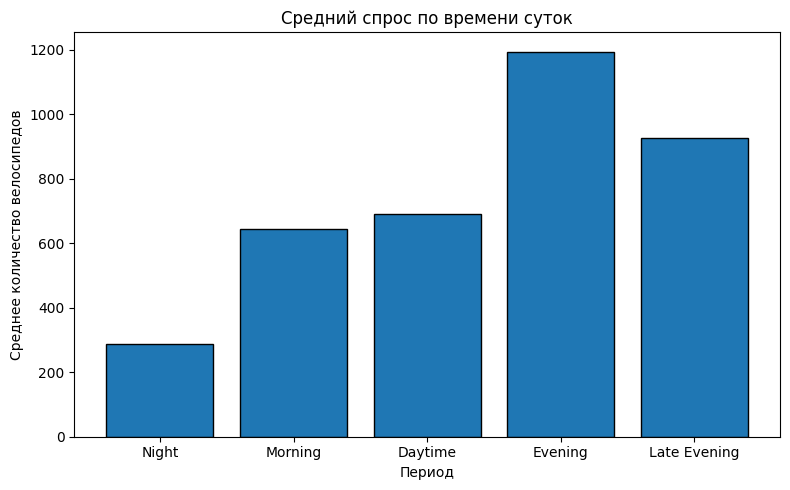

In [10]:
# Average demand by time periods
time_periods = {
    'Night': train_data['time_period_night'],
    'Morning': train_data['time_period_morning'],
    'Evening': train_data['time_period_evening'],
    'Late Evening': train_data['time_period_late_evening'],
}

# Restoring the Daytime period (all False)
daytime_mask = (
    ~train_data['time_period_night'] &
    ~train_data['time_period_morning'] &
    ~train_data['time_period_evening'] &
    ~train_data['time_period_late_evening']
)

period_means = {
    'Night': train_data[train_data['time_period_night']]['rented_bike_count'].mean(),
    'Morning': train_data[train_data['time_period_morning']]['rented_bike_count'].mean(),
    'Daytime': train_data[daytime_mask]['rented_bike_count'].mean(),
    'Evening': train_data[train_data['time_period_evening']]['rented_bike_count'].mean(),
    'Late Evening': train_data[train_data['time_period_late_evening']]['rented_bike_count'].mean(),
}

plt.figure(figsize=(8, 5))
plt.bar(period_means.keys(), period_means.values(), edgecolor='black')
plt.title('Average demand by time of day')
plt.xlabel('Period')
plt.ylabel('Average number of bikes')
plt.tight_layout()
plt.show()

for period, mean in period_means.items():
    print(f'{period:15}: {mean:.0f}')

### EDA Summary

**Numerical features:**
- **temperature** — this has the strongest correlation with the target variable: demand is highest at +15/+30 degrees, and close to zero at negative temperatures. A nonlinear relationship is observed (looks like an inverted parabola).
- **dew_point_temperature** — shows a pattern similar to the temperature dependency.
- **humidity** — an inverse relationship is observed: demand drops at high humidity (>80%) (which makes sense — people don’t ride bikes in the rain).
- **solar_radiation_mjm2** — a positive correlation is observed, but most values are 0 (these are nighttime hours).
- **rainfall, snowfall** — demand sharply decreases during precipitation, but most values are 0.
- **wind_speed_ms, visibility_10m** — a weak correlation is observed.

**Categorical features:**
- **seasons** — demand increases in summer and is about ~1030, while in winter it is lower at ~220 (almost a 5-fold difference).
- **holiday** — demand is noticeably lower on holidays (~500 vs ~720).
- **functioning_day** — demand is zero on non-working days (it is logical to assume bikes are serviced on these days and thus unavailable).

**Time series:**
- Peak demand occurs in the evening, as people return from work and may need a bike. The minimum is observed at night (~290).

Thus, all observed dependencies are clearly nonlinear. This explains the weakness of linear regression and provides grounds to expect improvements from kNN and decision trees.



---



## 3. Data Preparation

Based on EDA, we see that the data contains:
- numerical features with missing values
- categorical features (seasons, holiday, functioning_day)
- binary features of time periods (already in True/False format)

Let's prepare the data for model training:
1. Split into features (X) and target variable (y)
2. Create a ColumnTransformer for preprocessing
3. Leave the final test set untouched until the end of the project

In [11]:
# Split into features and target variable
X = train_data.drop('rented_bike_count', axis=1)
y = train_data['rented_bike_count']

# Feature groups
numerical_features = ['temperature', 'humidity', 'wind_speed_ms',
                      'visibility_10m', 'dew_point_temperature',
                      'solar_radiation_mjm2', 'rainfallmm', 'snowfall_cm']

categorical_features = ['seasons', 'holiday', 'functioning_day']

binary_features = ['time_period_evening', 'time_period_late_evening',
                   'time_period_morning', 'time_period_night']

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'),
     categorical_features),
    ('bin', 'passthrough', binary_features)
])

print('Size of X:', X.shape)
print('Size of y:', y.shape)
print('\nFeature groups:')
print(f'  Numerical:      {len(numerical_features)}')
print(f'  Categorical:    {len(categorical_features)}')
print(f'  Binary:         {len(binary_features)}')

Data is prepared. X contains 15 features, y is the target variable (7008 observations). Numerical features were filled with the median and standardized. Categorical features were encoded using One-Hot Encoding. Binary features of time periods were left as is.

## 4. Basic and Optimized Models

Before optimization, let's check that the pipelines work correctly —
train each model with basic parameters and evaluate through cross-validation.

In [12]:
# Basic kNN pipeline
pipeline_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=5))
])

# Basic decision tree pipeline
pipeline_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=5, random_state=42))
])

# Evaluation
for name, pipeline in [('kNN', pipeline_knn), ('Decision Tree', pipeline_tree)]:
    scores = cross_val_score(
        pipeline, X, y,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )
    rmse = -scores.mean()
    print(f'{name}: RMSE = {rmse:.4f}')

Even with basic parameters, both models are already better than the baseline.  
kNN shows a lower RMSE with default settings, and these are far from optimal values. After hyperparameter tuning, the results should improve.

### 4.1 Hyperparameter Optimization with Optuna

In [14]:
# kNN Optimization (alternative option)
def objective_knn(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 1, 30)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_int('p', 1, 2)
    algorithm = trial.suggest_categorical(
        'algorithm',
        ['auto', 'ball_tree', 'kd_tree', 'brute']
    )

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsRegressor(
            n_neighbors=n_neighbors,
            weights=weights,
            p=p,
            algorithm=algorithm
        ))
    ])

    scores = cross_val_score(
        pipeline, X, y,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )
    return scores.mean()

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=50)

print('Best kNN parameters:')
print(study_knn.best_params)
print(f'Best RMSE (CV): {-study_knn.best_value:.2f}')

In [15]:
# Decision tree optimization
def objective_tree(trial):
    max_depth = trial.suggest_int('max_depth', 2, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical(
        'max_features',
        [None, 'sqrt', 'log2']
    )

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42
        ))
    ])

    scores = cross_val_score(
        pipeline, X, y,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )
    return scores.mean()

In [16]:
study_tree = optuna.create_study(direction='maximize')
study_tree.optimize(objective_tree, n_trials=50)

print('Best decision tree parameters:')
print(study_tree.best_params)
print(f'Best RMSE (CV): {-study_tree.best_value:.2f}')



---



## 5. Comparison of Models and Selection of the Best One

Let's compare all the models based on the cross-validation results.

In [17]:
# Best pipelines with optimal parameters
best_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(**study_knn.best_params))
])

best_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(
        **study_tree.best_params,
        random_state=42
    ))
])

# Calculate all metrics through cross-validation
results = {}

for name, pipeline in [('kNN', best_knn), ('Decision Tree', best_tree)]:
    rmse_scores = cross_val_score(
        pipeline, X, y, cv=5,
        scoring='neg_root_mean_squared_error'
    )
    mae_scores = cross_val_score(
        pipeline, X, y, cv=5,
        scoring='neg_mean_absolute_error'
    )
    r2_scores = cross_val_score(
        pipeline, X, y, cv=5,
        scoring='r2'
    )
    results[name] = {
        'RMSE': -rmse_scores.mean(),
        'MAE': -mae_scores.mean(),
        'R2': r2_scores.mean()
    }

# Add baseline
results['Baseline (LR)'] = {
    'RMSE': 411.45,
    'MAE': 312.53,
    'R2': 0.5863
}

print(f'{"Model":<20} {"RMSE":>8} {"MAE":>8} {"R2":>8}')
print('-' * 45)
for name, metrics in results.items():
    print(f'{name:<20} {metrics["RMSE"]:>8.2f} {metrics["MAE"]:>8.2f} {metrics["R2"]:>8.4f}')

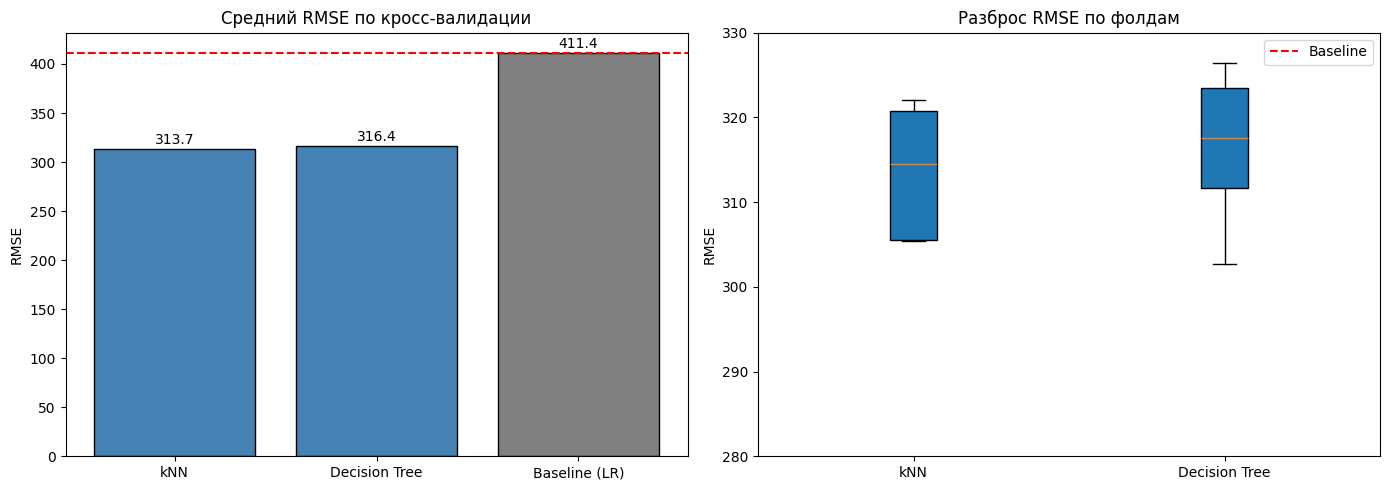

In [18]:
# Collect RMSE for each fold for both models
knn_folds = -cross_val_score(
    best_knn, X, y, cv=5,
    scoring='neg_root_mean_squared_error'
)

tree_folds = -cross_val_score(
    best_tree, X, y, cv=5,
    scoring='neg_root_mean_squared_error'
)

# Bar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean values
models = ['kNN', 'Decision Tree', 'Baseline (LR)']
rmse_means = [knn_folds.mean(), tree_folds.mean(), 411.45]
colors = ['steelblue', 'steelblue', 'gray']

axes[0].bar(models, rmse_means, color=colors, edgecolor='black')
axes[0].set_title('Average RMSE from cross-validation')
axes[0].set_ylabel('RMSE')
axes[0].axhline(y=411.45, color='red', linestyle='--', label='Baseline')
for i, v in enumerate(rmse_means):
    axes[0].text(i, v + 5, f'{v:.1f}', ha='center')

# Box plot
axes[1].boxplot([knn_folds, tree_folds],
                tick_labels=['kNN', 'Decision Tree'],
                patch_artist=True)
axes[1].axhline(y=411.45, color='red', linestyle='--', label='Baseline')
axes[1].set_title('RMSE spread across folds')
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].set_ylim(280, 330)

plt.tight_layout()
plt.show()

# Table by folds
print(f'{"Fold":<8} {"kNN":>10} {"Decision Tree":>15}')
print('-' * 45)
for i, (k, t) in enumerate(zip(knn_folds, tree_folds)):
    print(f'{i+1:<8} {k:>10.2f} {t:>15.2f}')
print('-' * 45)
print(f'{"Mean":<8} {knn_folds.mean():>10.2f} {tree_folds.mean():>15.2f}')
print(f'{"Std":<8} {knn_folds.std():>10.2f} {tree_folds.std():>15.2f}')

Both models are significantly better than the baseline across all folds. The kNN model turned out to be better according to two criteria: lower RMSE: 313.65 vs 316.35; and more stable standard deviation (7.13 vs 8.51 for the decision tree).

The boxplot shows that the kNN box is narrower and positioned lower — this means the model consistently shows good results across all folds. The decision tree has a visually larger spread.

So, the best model is kNN with parameters `n_neighbors=10, weights='distance', p=1, algorithm = 'ball_tree'`.



---



## 6. Model Report

Summary table of metrics and visualization of results for all models.

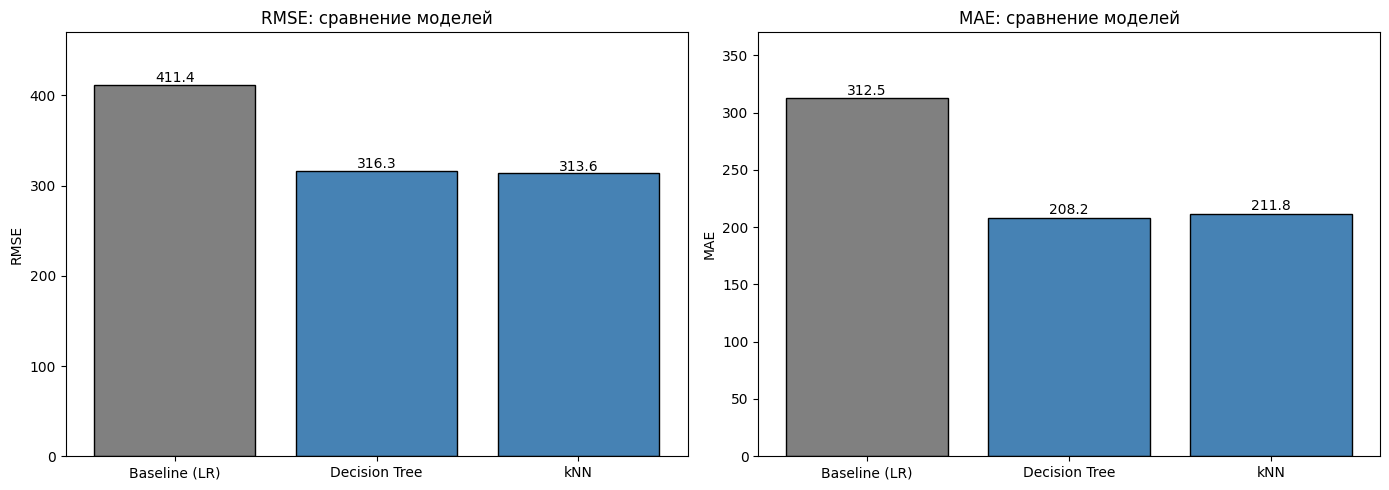

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Baseline (LR)', 'Decision Tree', 'kNN']
rmse_values = [411.45, 316.33, 313.65]
mae_values  = [312.53, 208.18, 211.85]
colors = ['gray', 'steelblue', 'steelblue']

# RMSE
bars = axes[0].bar(models, rmse_values, color=colors, edgecolor='black')
axes[0].set_title('RMSE: model comparison')
axes[0].set_ylabel('RMSE')
for bar, v in zip(bars, rmse_values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 v + 3, f'{v:.1f}', ha='center')
axes[0].set_ylim(0, 470)

# MAE
bars = axes[1].bar(models, mae_values, color=colors, edgecolor='black')
axes[1].set_title('MAE: model comparison')
axes[1].set_ylabel('MAE')
for bar, v in zip(bars, mae_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + 3, f'{v:.1f}', ha='center')
axes[1].set_ylim(0, 370)

plt.tight_layout()
plt.show()

# Final table
print(f'{"Model":<20} {"RMSE":>8} {"MAE":>8} {"R2":>8}')
print('-' * 45)
print(f'{"Baseline (LR)":<20} {411.45:>8.2f} {312.53:>8.2f} {0.5863:>8.4f}')
print(f'{"Decision Tree (CV)":<20} {316.35:>8.2f} {208.18:>8.2f} {0.7603:>8.4f}')
print(f'{"kNN (CV)":<20} {313.65:>8.2f} {211.85:>8.2f} {0.7640:>8.4f}')

**Business Interpretation:**

- The typical kNN forecast error is about 211 bikes per hour.  
  This means that if the model predicts 500 bikes,  
  the actual demand is most likely in the range of 289–711.

- Linear regression performed poorly with nonlinear dependencies:  
  for example, at +5°C and +25°C the demand is completely different,  
  but the linear model did not capture this difference correctly.

- kNN responds well to weather patterns: in hours with similar weather  
  the demand will be similar — this is exactly what the algorithm uses.


kNN does not have a built-in feature importance evaluation mechanism, so based on EDA the most influential factors are:  
- **Temperature** — this is our main demand driver  
- **Season** — in summer demand is 5 times higher than in winter  
- **Time of day** — there is a peak in the evening (after work)  
- **Precipitation** — adverse weather conditions such as rain or snow sharply reduce demand  
- **Functioning Day** — on maintenance days demand is zero

Since the kNN model only slightly outperforms the decision tree model, we can assess feature importance through it and verify our empirical conclusions.

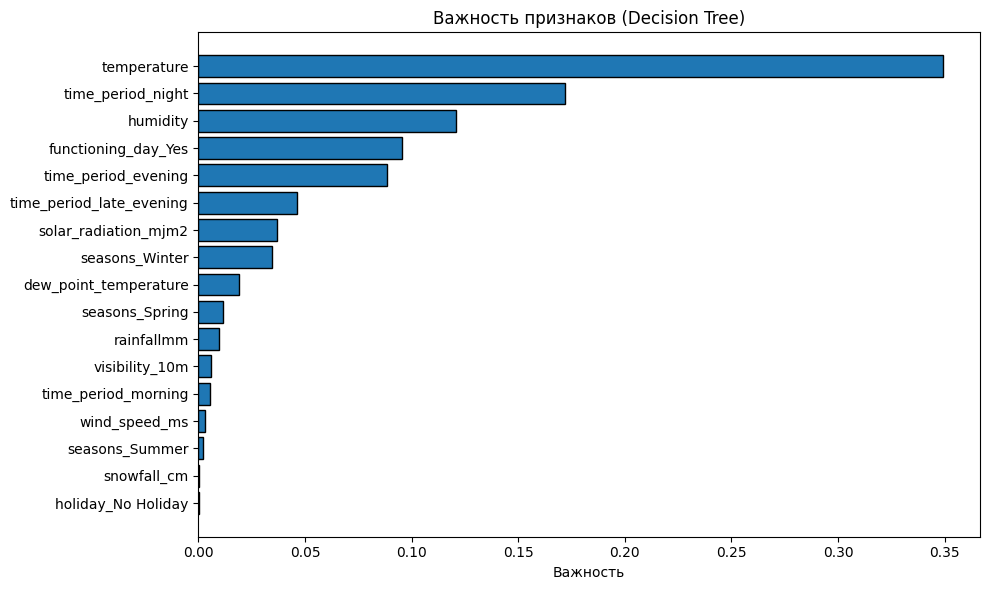

In [20]:
# Train the decision tree on all training data
best_tree.fit(X, y)

# Get feature names after preprocessing
cat_features_encoded = best_tree.named_steps['preprocessor']\
    .named_transformers_['cat'].get_feature_names_out(categorical_features)

feature_names = (numerical_features +
                 list(cat_features_encoded) +
                 binary_features)

# Feature importance
importances = best_tree.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Visualization
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'],
         importance_df['Importance'],
         edgecolor='black')
plt.title('Feature Importance (Decision Tree)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

**Interpretation in a business context using the decision tree model:**

1. **Temperature (35%)** — this is the main driver of demand. The model captures the nonlinear relationship well: at -10C people do not rent bikes, at +25C they rent actively. Linear regression did not capture this relationship.

2. **Night time (17%)** — demand drops sharply at night. The model accurately identifies the "dead hours" and does not overestimate the forecast.

3. **Humidity (12%)** — at high humidity (rain, fog, etc.) people avoid bikes. The model responds better to bad weather than the baseline.

4. **Functioning Day (9.5%)** — on maintenance days demand is zero. This is a strict rule that the tree learned perfectly.

5. **Evening time (8.8%)** — this is the peak demand after work. The model accurately forecasts the evening rush hours.

6. **Winter (3.5%)** — in winter demand is 5 times lower than in summer.

**Main conclusion:** - bike demand is primarily determined by weather (temperature + humidity = 47%) and time of day (~27%). This is hard to notice for the kNN model, but our findings and assumptions align with what we see from the decision tree.



---



## 7. Final Evaluation of the Best Model

In [24]:
best_knn.fit(X, y)

# Load the test dataset
test_data = test_data.rename(columns=rename_map)

X_test = test_data.drop('rented_bike_count', axis=1)
y_test = test_data['rented_bike_count']

# Predictions
y_pred = best_knn.predict(X_test)

# Metrics
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
mae_test  = mean_absolute_error(y_test, y_pred)
r2_test   = r2_score(y_test, y_pred)

print('Final evaluation on the test dataset')
print(f'{"":15} {"RMSE":>8} {"MAE":>8} {"R2":>8}')
print('-' * 45)
print(f'{"kNN (test)":15} {rmse_test:>8.2f} {mae_test:>8.2f} {r2_test:>8.4f}')
print(f'{"kNN (CV)":15} {313.65:>8.2f} {211.85:>8.2f} {0.7740:>8.4f}')
print(f'{"Baseline":15} {411.45:>8.2f} {312.53:>8.2f} {0.5863:>8.4f}')

1. **The model did not overfit** — our test results (312.06) are close
   to cross-validation (317.96), a difference of almost 1%. This means
   the model generalizes well to new data.

2. **Improvement compared to baseline:**
   - RMSE decreased by **24%**: from 411 to 312
   - MAE decreased by **33%**: from 312 to 212
   - R2 increased from **0.59 to 0.75**: this means the model now explains
     75% of the demand variance instead of 59%

The typical forecast error also decreased by about 100 bikes per hour. For BikeSochi, this means more accurate planning, and therefore fewer empty stations during peak hours and less downtime during quiet hours.

In [22]:
# saving the model
joblib.dump(best_knn, 'best_knn_pipeline.joblib')

## 8. Final conclusions and recommendations for BikeSochi

### Project Summary

**Model selection:**
For production, a kNN model with parameters `n_neighbors=10, weights='distance', p=1,  algorithm = 'ball_tree'` is proposed. The model was chosen based on criteria such as the best RMSE in cross-validation (313.65 (vs 316.35 for the tree)) and a more stable std (7.13 (vs 8.51 for the tree)), while the test results are close to CV (our model does not overfit).

**Recommendations for BikeSochi:**

1. **Implement the kNN model** instead of linear regression: with it, the forecast error will decrease by about 100 bikes per hour.

2. **Monitor temperature and humidity**: these two features explain ~47% of demand. When the weather changes sharply, the model will automatically adjust the forecast.

3. **Plan maintenance in advance**: on days when demand is zero, this can be used to optimize the maintenance schedule.

4. **Increase the bike fleet in summer and evenings**: in summer, demand is 5 times higher than in winter, and the peak falls on evening hours (16-20).

5. **Ways to improve the model:**
   - Add real-time data (for example, hour of the day instead of periods)
   - Try ensemble methods — Random Forest, Gradient Boosting
   - Collect more data over different years to account for trends